In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## Load data

In [2]:
DATA_PATH=Path('data/cookie_cats.csv')
df=pd.read_csv(DATA_PATH)
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


## first 5 row

In [3]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [5]:
df.shape

(90189, 5)

In [6]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [7]:
df[df.duplicated()]

,userid,version,sum_gamerounds,retention_1,retention_7


In [8]:
df[df.duplicated('userid')]

,userid,version,sum_gamerounds,retention_1,retention_7


In [9]:
df['userid'].nunique()

90189

In [10]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## Sanity check

In [11]:
df.groupby('version')['userid'].count()

version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64

In [12]:
df.groupby('version')['userid'].count()

version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64

In [13]:
df.groupby('version')[['retention_1', 'retention_7']].agg(['count','median','mean','std']).T

version                  gate_30       gate_40
retention_1 count   44700.000000  45489.000000
            median      0.000000      0.000000
            mean        0.448188      0.442283
            std         0.497314      0.496663
retention_7 count   44700.000000  45489.000000
            median      0.000000      0.000000
            mean        0.190201      0.182000
            std         0.392464      0.385849

## Check sum_gamerounds variable

In [14]:
df.groupby('version')['sum_gamerounds'].agg(['count','median','mean','std','max','min'])

,count,median,mean,std,max,min
version,,,,,,
gate_30,44700,17.0,52.456264,256.716423,49854,0
gate_40,45489,16.0,51.298776,103.294416,2640,0


In [15]:
for_plot=df.groupby('sum_gamerounds')['userid'].count()

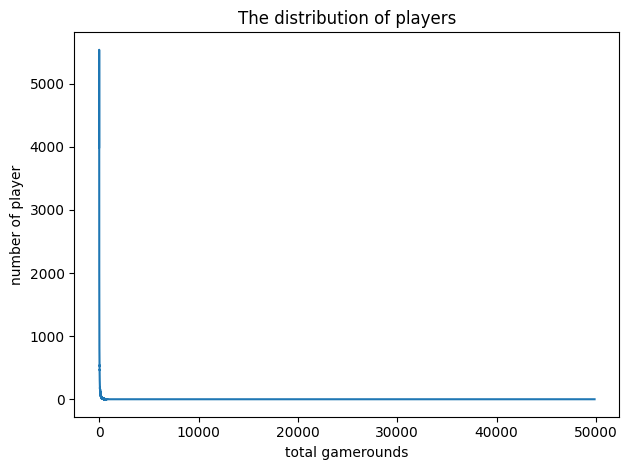

In [16]:
sns.lineplot(data=for_plot)
plt.title("The distribution of players")
plt.xlabel("total gamerounds")
plt.ylabel("number of player")
plt.tight_layout()
plt.show()

## Too many data

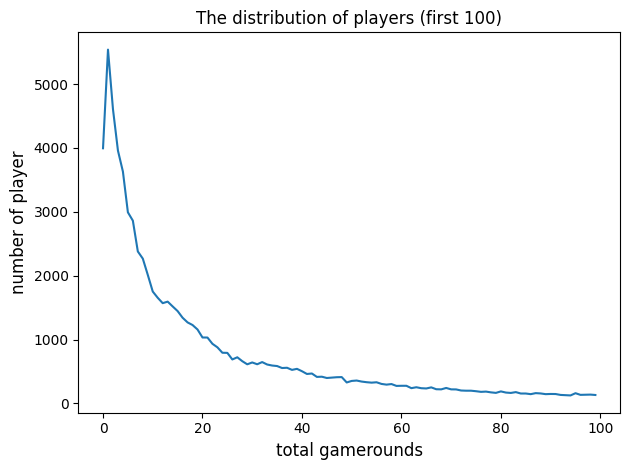

In [17]:
sns.lineplot(data=for_plot.head(100))
plt.title("The distribution of players (first 100)")
plt.xlabel("total gamerounds", size=12)
plt.ylabel("number of player", size=12)
plt.tight_layout()
plt.show()

In [18]:
never_played=df[df["sum_gamerounds"]== 0]["userid"].count()
print(f'Install but then never play: {never_played}')

Install but then never play: 3994


## More data visualization 

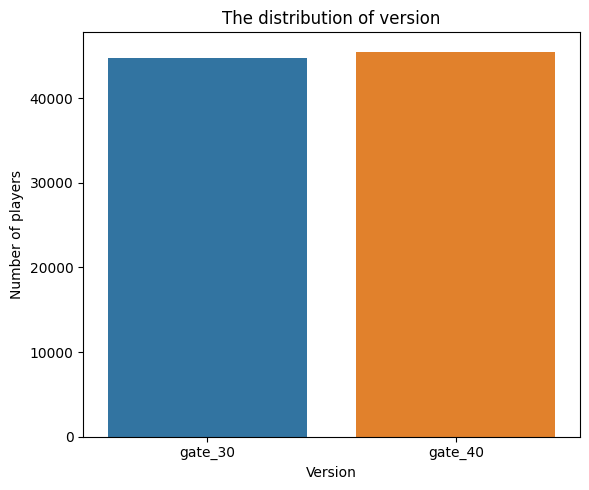

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='version',hue='version')
plt.title('The distribution of version')
plt.xlabel("Version")
plt.ylabel("Number of players")
plt.tight_layout()
plt.show()

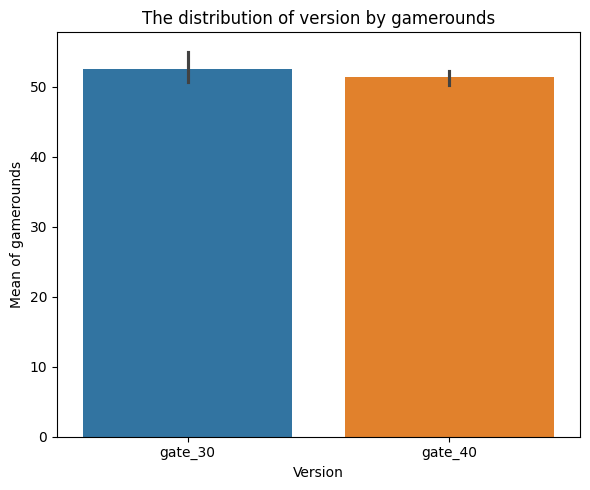

In [20]:
plt.figure(figsize=(6,5))
sns.barplot(data=df,x='version',y='sum_gamerounds',hue='version')
plt.title('The distribution of version by gamerounds')
plt.xlabel("Version")
plt.ylabel("Mean of gamerounds")
plt.tight_layout()
plt.show()

## Check for outliers

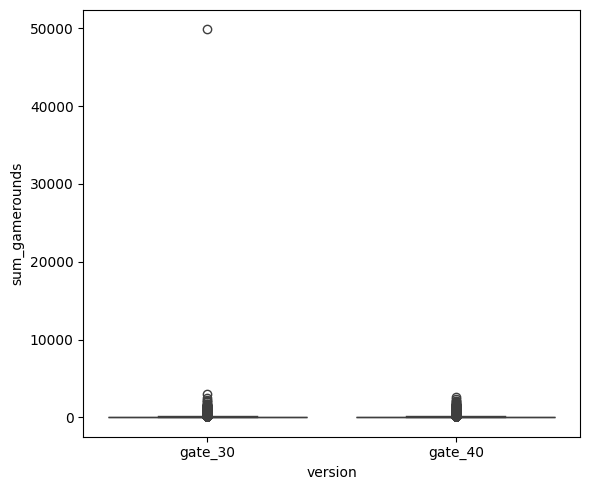

In [21]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df,x='version',y='sum_gamerounds',hue='version')
plt.tight_layout()
plt.show()

In [22]:
Q1=df['sum_gamerounds'].quantile(0.25)
Q3=df['sum_gamerounds'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
high_bound=Q3+1.5*IQR


In [23]:
print(f'IQR: {IQR}, lowerbound: {lower_bound}, highbound: {high_bound}')

IQR: 46.0, lowerbound: -64.0, highbound: 120.0


## Because the data is right-skewed, we need to try different quantile 

In [24]:
Q99=df['sum_gamerounds'].quantile(0.99)

In [25]:
Q999=df['sum_gamerounds'].quantile(0.999).round(0)

In [26]:
df[df['sum_gamerounds']<0]

,userid,version,sum_gamerounds,retention_1,retention_7


## Drop 

In [27]:
df_clean=df[df['sum_gamerounds']<=Q999]

## After cleaning

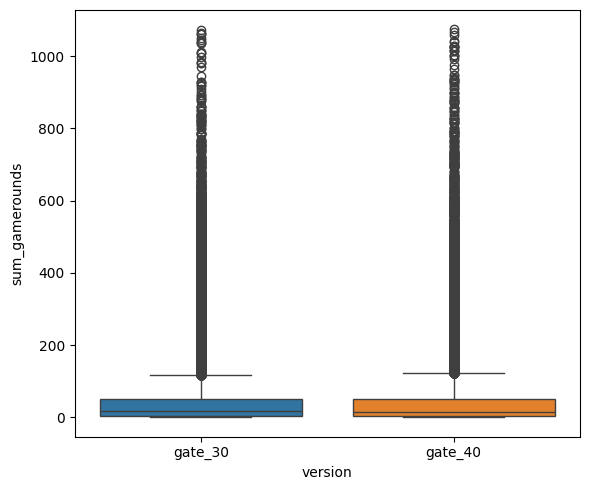

In [28]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df_clean,x='version',y='sum_gamerounds',hue='version')
plt.tight_layout()
plt.show()

In [29]:
df_clean.groupby('version')[['retention_1', 'retention_7']].agg(['count','median','mean','std']).T

version                  gate_30       gate_40
retention_1 count   44659.000000  45440.000000
            median      0.000000      0.000000
            mean        0.447704      0.441725
            std         0.497263      0.496598
retention_7 count   44659.000000  45440.000000
            median      0.000000      0.000000
            mean        0.189458      0.181140
            std         0.391876      0.385138

In [30]:
df_clean.to_csv('data/clean_cookie_cats.csv',index=False)